# Data Wrangling & Exploration

**1. Data Cleaning**

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
from datetime import datetime
from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split



In [112]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/titanic-dataset


In [113]:
os.listdir(path)

['Titanic-Dataset.csv']

In [114]:
data=pd.read_csv(path+"/Titanic-Dataset.csv")
data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [115]:
data=pd.DataFrame(data)

In [116]:
data.drop("Name",axis=1,inplace=True)
data.drop("PassengerId",axis=1,inplace=True)
data.drop("Ticket",axis=1,inplace=True)
data.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S
5,0,3,male,NaN,0,0,8.4583,NaN,Q
6,0,1,male,54.0,0,0,51.8625,E46,S
7,0,3,male,2.0,3,1,21.0750,NaN,S
8,1,3,female,27.0,0,2,11.1333,NaN,S
9,1,2,female,14.0,1,0,30.0708,NaN,C


In [117]:
data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [118]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [119]:
data["Cabin"]

,Cabin
0,NaN
1,C85
2,NaN
3,C123
4,NaN
...,...
886,NaN
887,B42
888,NaN
889,C148


In [120]:
date_strings = ['2025-01-01', '2024-02-15', '2023-03-20']
df = pd.DataFrame({'date_col': date_strings})

df['date_col'] = pd.to_datetime(df['date_col'])
df

,date_col
0,2025-01-01
1,2024-02-15
2,2023-03-20


In [121]:
#rename
df = df.rename(columns={"date_col": "Date"})
df

,Date
0,2025-01-01
1,2024-02-15
2,2023-03-20


In [122]:
#drop col
df.drop("Date",axis=1)


""
0
1
2


In [123]:
#reset index
df.reset_index(drop=True)


,Date
0,2025-01-01
1,2024-02-15
2,2023-03-20


**2.Exploratory Data Analysis (EDA)**

In [124]:
data.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,2


In [125]:
#most frequent value
freq_cabin = data['Cabin'].mode()[0]
freq_embarked=data['Embarked'].mode()[0]
freq_embarked

'S'

In [126]:
data["Age"].fillna(data["Age"].mean(),inplace=True)
data["Cabin"].fillna(freq_cabin, inplace=True)
data["Embarked"].fillna(freq_embarked, inplace=True)

In [127]:
data.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0


In [128]:
data["Embarked"].unique()

array(['S', 'C', 'Q'], dtype=object)

In [129]:
#label encoder
encoder=LabelEncoder()
data["Sex"]=encoder.fit_transform(data["Sex"])
data["Cabin"]=encoder.fit_transform(data["Cabin"])
data["Embarked"]=encoder.fit_transform(data["Embarked"])


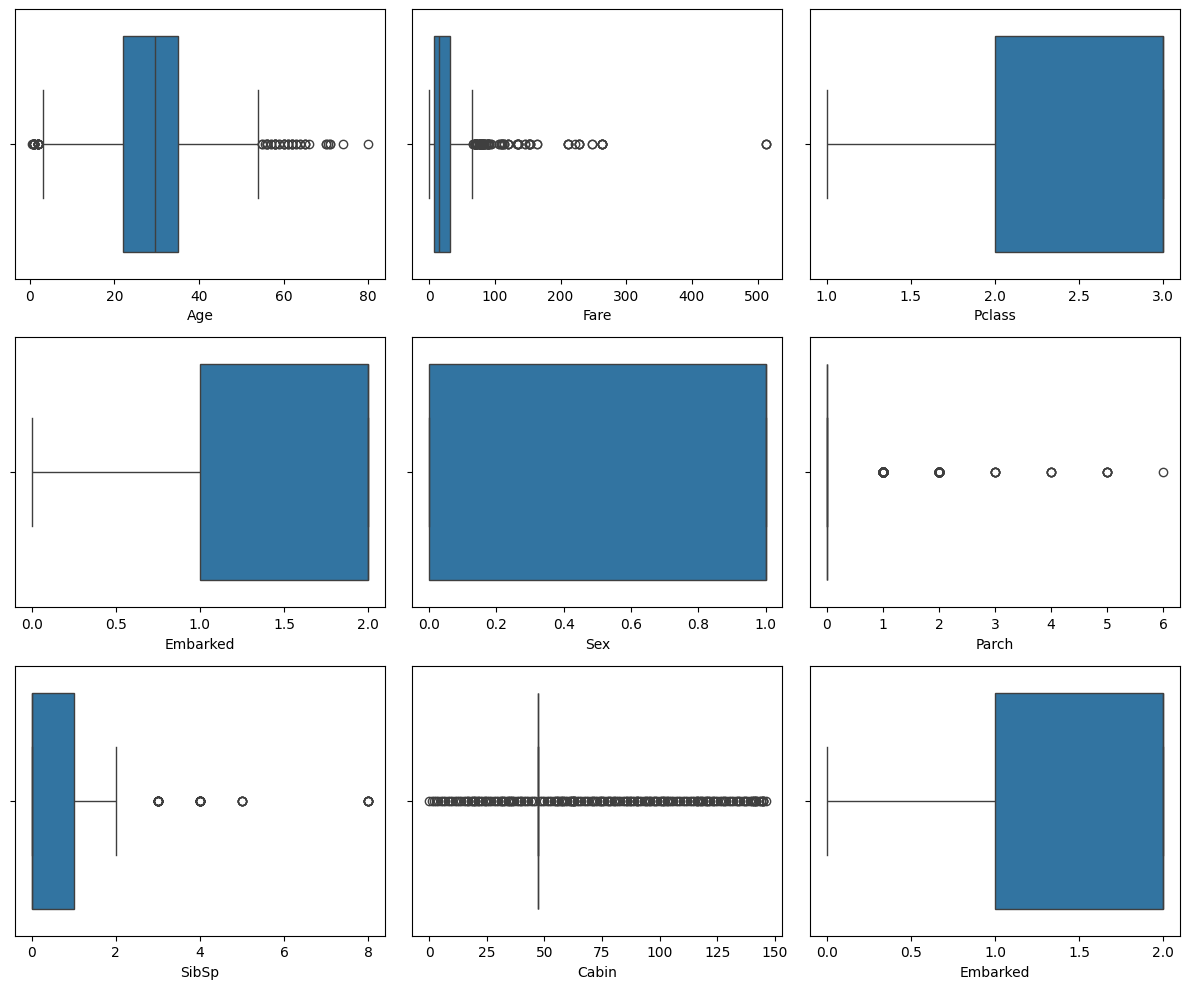

In [130]:
#check outliers (box plot)

list=["Age","Fare","Pclass","Embarked","Sex","Parch","SibSp","Cabin","Embarked"]
figure,axes=plt.subplots(nrows=3,ncols=3,figsize=(12,10))
axes=axes.flatten()
for i,col in enumerate(list):
    sns.boxplot(data=data,x=col,ax=axes[i])
plt.tight_layout()
plt.show()

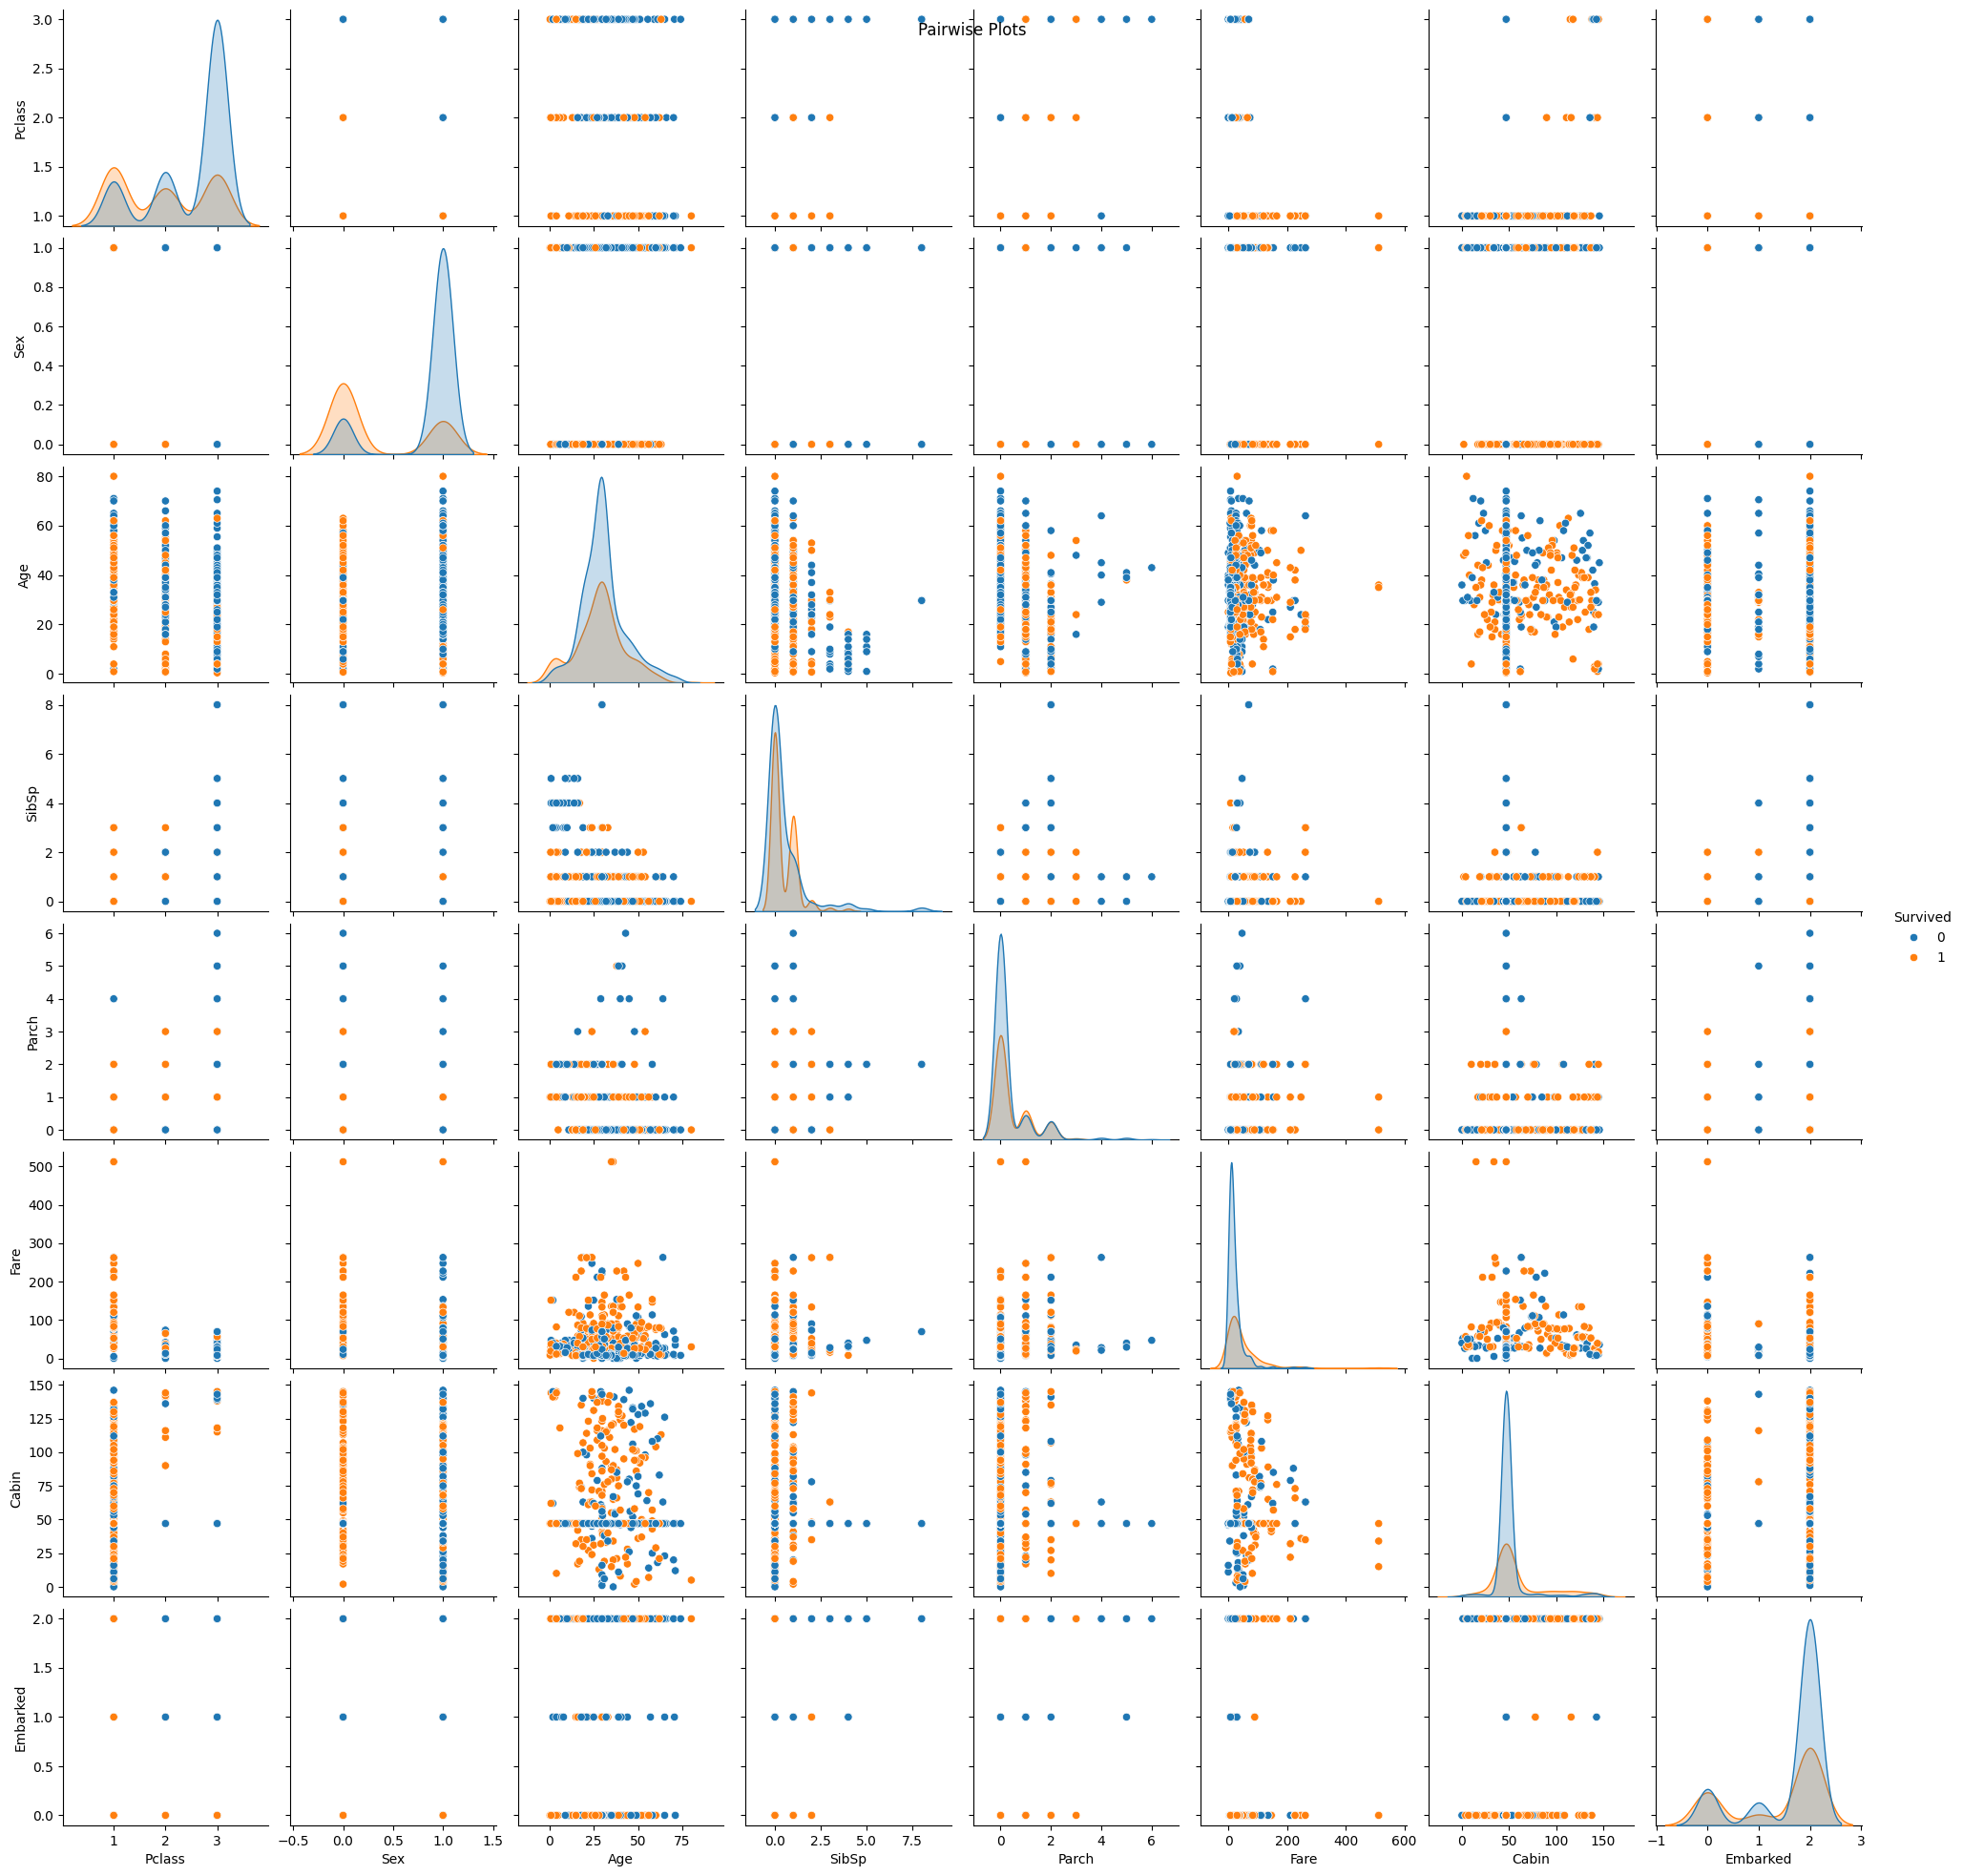

In [131]:
sns.pairplot(data, hue="Survived")
plt.suptitle("Pairwise Plots")
plt.show()

Survived
0    549
1    342
Name: count, dtype: int64


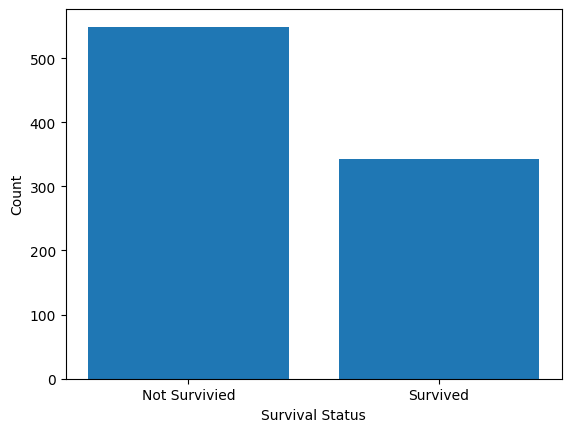

In [132]:
#ratio of servival and non-servival
# Calculate the count of survivors and non-survivors
survived_counts= data['Survived'].value_counts() # return unqiue values and its occurances
print(survived_counts)
# Create the bar plot

plt.bar(survived_counts.index, survived_counts.values)  # Provide both x and height

# Set labels and title for clarity
plt.xticks([0, 1],['Not Survivied','Survived'])  # Set x-axis ticks for 0 and 1 (not survived/survived) respectively
plt.xlabel('Survival Status')
plt.ylabel('Count')
plt.show()


Pclass
3    491
1    216
2    184
Name: count, dtype: int64


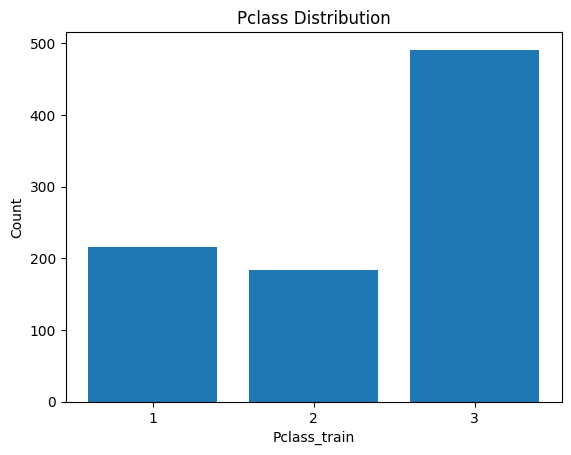

In [133]:
#which Pclass get more death or survival rate ?
pclass_counts = data['Pclass'].value_counts() # unique value, count
print(pclass_counts)

plt.bar(pclass_counts.index,pclass_counts.values)
plt.xticks(pclass_counts.index)
plt.title('Pclass Distribution')

plt.xlabel('Pclass_train')
plt.ylabel('Count')

plt.show()

Sex  Survived
0    0            81
     1           233
1    0           468
     1           109
Name: Sex, dtype: int64


Text(0, 0.5, 'Count')

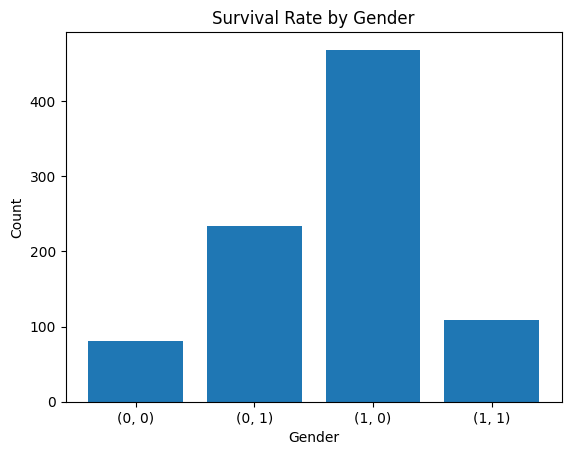

In [134]:
#Bivariante Analysis: on base of sex

#groupby statement used
count_=data.groupby(['Sex','Survived'])['Sex'].count()

print(count_)
x_labels = [str(idx) for idx in count_.index] # Convert tuples to strings

plt.bar(x_labels,count_.values)
plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')



Pclass  Survived
1       0            80
        1           136
2       0            97
        1            87
3       0           372
        1           119
Name: Pclass, dtype: int64


Text(0, 0.5, 'Count')

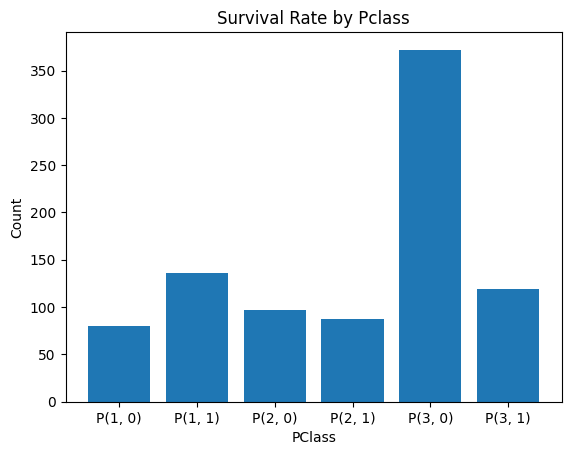

In [135]:
#survival rate on base of PCLASS
pclass=data.groupby(['Pclass','Survived'])['Pclass'].count()

print(pclass)
x_labels = [str('P')+str(idx) for idx in pclass.index] # Convert tuples to strings


plt.bar(x_labels,pclass.values)
plt.title('Survival Rate by Pclass')
plt.xlabel('PClass')
plt.ylabel('Count')

#p(1,0)>>> represent it belong to class 1 and 0 mean not survive

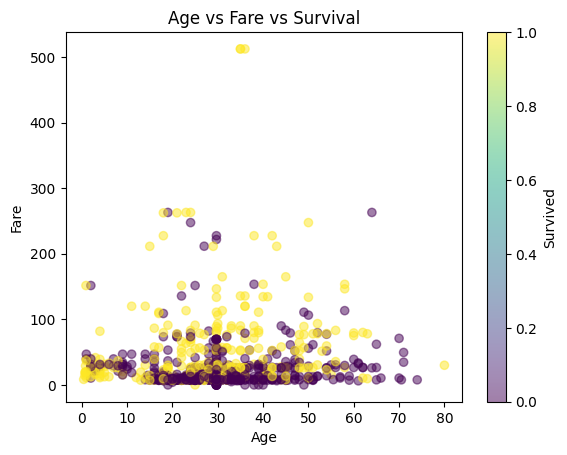

In [136]:
#fare with survival
plt.scatter(data['Age'], data['Fare'],c=data['Survived'],cmap='viridis', alpha=0.5)
plt.title('Age vs Fare vs Survival')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.colorbar(label='Survived')  # Add color bar for reference
plt.show()

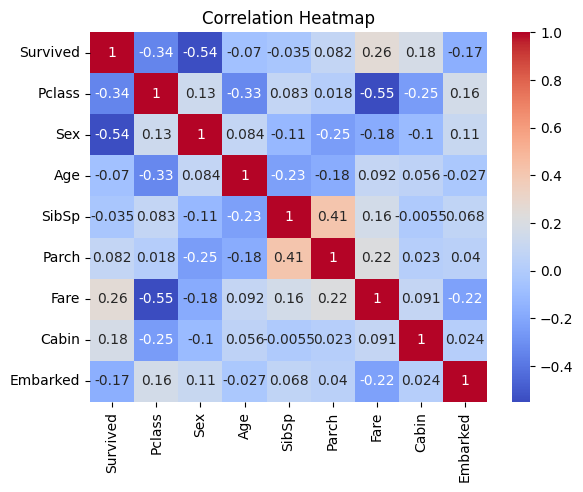

In [137]:
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Feature Engineering**

In [138]:
#new feature (e.g., extract day/month/year from date)
current_datetime = datetime.now()

# Print the full datetime object
print("Current date and time:", current_datetime)

# Access individual components
print("Year:", current_datetime.year)
print("Month:", current_datetime.month)
print("Day:", current_datetime.day)
print("Hour:", current_datetime.hour)
print("Minute:", current_datetime.minute)
print("Second:", current_datetime.second)
print("Microsecond:", current_datetime.microsecond)

# Create a DataFrame with the current datetime
d = pd.DataFrame({'Date': [current_datetime]})
display(d)

Current date and time: 2025-06-28 16:25:17.903853
Year: 2025
Month: 6
Day: 28
Hour: 16
Minute: 25
Second: 17
Microsecond: 903853


,Date
0,2025-06-28 16:25:17.903853


In [139]:
#Normalize or standardize (to make each attribute in specfic range )
scaler=MinMaxScaler()
scaler.fit_transform(data)

array([[0.        , 1.        , 1.        , ..., 0.01415106, 0.32191781,
        1.        ],
       [1.        , 0.        , 0.        , ..., 0.13913574, 0.55479452,
        0.        ],
       [1.        , 1.        , 0.        , ..., 0.01546857, 0.32191781,
        1.        ],
       ...,
       [0.        , 1.        , 0.        , ..., 0.04577135, 0.32191781,
        1.        ],
       [1.        , 0.        , 1.        , ..., 0.0585561 , 0.4109589 ,
        0.        ],
       [0.        , 1.        , 1.        , ..., 0.01512699, 0.32191781,
        0.5       ]])